In [70]:
import numpy as np
import pandas as pd
import ast
import json
import os


import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score

In [5]:
TRAIN_PATH = "Data_path/data/data/train"
TEST_PATH =  "Data_path/data/data/test"
LABELS = "Data_path/labeled_anomalies.csv"

In [6]:
df_anomalies = pd.read_csv(LABELS)
df_anomalies.info()
df_anomalies.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   chan_id            82 non-null     str  
 1   spacecraft         82 non-null     str  
 2   anomaly_sequences  82 non-null     str  
 3   class              82 non-null     str  
 4   num_values         82 non-null     int64
dtypes: int64(1), str(4)
memory usage: 3.3 KB


,chan_id,spacecraft,anomaly_sequences,class,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505
1,S-1,SMAP,"[[5300, 5747]]",[point],7331
2,E-1,SMAP,"[[5000, 5030], [5610, 6086]]","[contextual, contextual]",8516
3,E-2,SMAP,"[[5598, 6995]]",[point],8532
4,E-3,SMAP,"[[5094, 8306]]",[point],8307
5,E-4,SMAP,"[[5450, 8261]]",[point],8354
6,E-5,SMAP,"[[5600, 5920]]",[point],8294
7,E-6,SMAP,"[[5610, 5675]]",[point],8300
8,E-7,SMAP,"[[5394, 5674]]",[point],8310
9,E-8,SMAP,"[[5400, 6022]]",[point],8532


Description of labels:

- **channel_id** is the id related to a telemetry acquired by spacecraft/staellite;
- **spacecraft** could be SMAP or MSL;
- **anomaly_sequence** is telling windows corresponding to an anomalies inside that telemetry;
- **class** is telling which type of anomaly is: a *point anomaly* can be identified by properly set alarms or distance-based methods that ignore temporal information, *contextual* require more complex methodologies such as LSTMs or Hierarchical Temporal Memory (HTM) approaches;
- **num_values** is telling how many timestamps of observations the telemetry has.

Description of train/test:
In practice, each channel of train/test is a telemetry, and each telemetry is a **temporal matrix** containing T(num_values) x 25(channels of each variable) samples. 

**However, the first channel (channel 0) is the main one capturing the signal while other are auxilisry channels recording, for instace, commands given to satellite, hence all values inside other channels are almost always 0.**

In [8]:
df_SMAP_anomalies = df_anomalies[df_anomalies['spacecraft'] == 'SMAP']
print(len(df_SMAP_anomalies['chan_id'].unique()))

54


Below, we just want to visualize an example of anomaly on channel 0 of a random telemetry.

Selected telemetry: E-8
Anomaly of telemetry: [[5400 6022]]


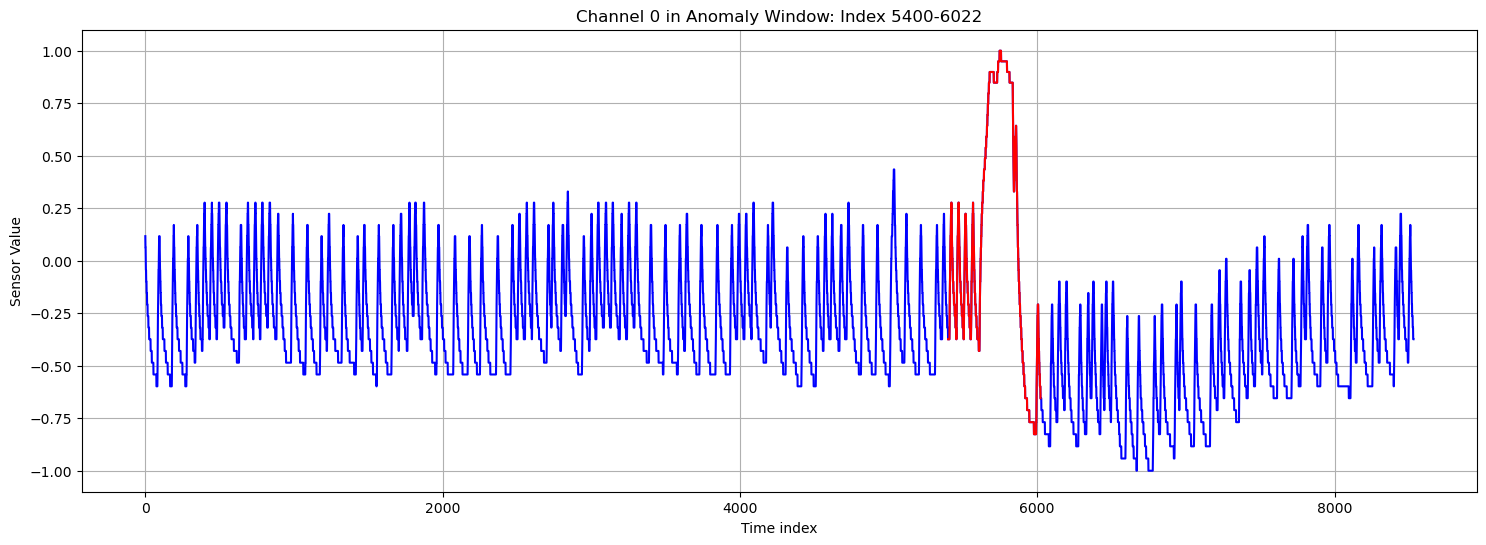

In [17]:
np.random.seed(10)
telemetry_pos = np.random.randint(0,54)
telemetry_name = df_SMAP_anomalies['chan_id'].iloc[telemetry_pos]
print(f'Selected telemetry: {telemetry_name}')

test_data = np.load(TEST_PATH + '/' + telemetry_name + '.npy')

anomalies = df_SMAP_anomalies[df_SMAP_anomalies['chan_id'] == telemetry_name]['anomaly_sequences'].values[0]
anomaly = np.fromstring(anomalies.replace("[", "").replace("]", ""),sep=",",dtype=int).reshape(-1, 2)
print(f'Anomaly of telemetry: {anomaly}')

#just to plot
anomaly_start,anomaly_end = (anomaly[0][0],anomaly[0][1]) if len(anomaly) <= 1 else (anomaly[-1][0],anomaly[-1][1])

plt.figure(figsize=(18,6))

time_indices_anomlay = np.arange(anomaly_start,anomaly_end+1)
time_indices = np.arange(test_data.shape[0])

channel_0_data_anomaly = test_data[anomaly_start:anomaly_end+1,0]
channel_0_data = test_data[:,0]

plt.plot(time_indices,channel_0_data,color='blue')
plt.plot(time_indices_anomlay,channel_0_data_anomaly,color='red')
plt.title(f"Channel 0 in Anomaly Window: Index {anomaly_start}-{anomaly_end}")
plt.xlabel('Time index')
plt.ylabel('Sensor Value')
plt.grid(True)

plt.show()

The one reported, is one of anomalies classified as "contextual" as its behavior is anomalous if compared within the context, but not all anomalies are in this way in this dataset.

Selected telemetry: R-1
Anomaly of telemetry: [[4510 4590]]


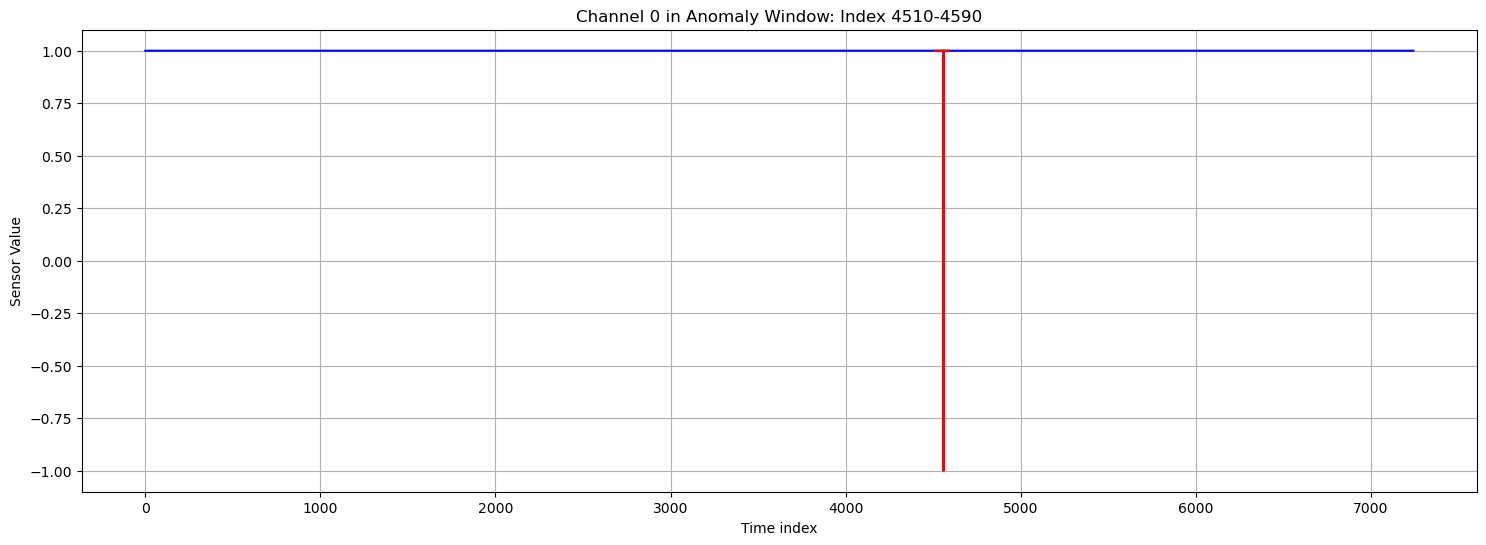

In [18]:
np.random.seed(4)
telemetry_pos = np.random.randint(0,54)
telemetry_name = df_SMAP_anomalies['chan_id'].iloc[telemetry_pos]
print(f'Selected telemetry: {telemetry_name}')

test_data = np.load(TEST_PATH + '/' + telemetry_name + '.npy')

anomalies = df_SMAP_anomalies[df_SMAP_anomalies['chan_id'] == telemetry_name]['anomaly_sequences'].values[0]
anomaly = np.fromstring(anomalies.replace("[", "").replace("]", ""),sep=",",dtype=int).reshape(-1, 2)
print(f'Anomaly of telemetry: {anomaly}')

#just to plot
anomaly_start,anomaly_end = (anomaly[0][0],anomaly[0][1]) if len(anomaly) <= 1 else (anomaly[-1][0],anomaly[-1][1])

plt.figure(figsize=(18,6))

time_indices_anomlay = np.arange(anomaly_start,anomaly_end+1)
time_indices = np.arange(test_data.shape[0])

channel_0_data_anomaly = test_data[anomaly_start:anomaly_end+1,0]
channel_0_data = test_data[:,0]

plt.plot(time_indices,channel_0_data,color='blue')
plt.plot(time_indices_anomlay,channel_0_data_anomaly,color='red')
plt.title(f"Channel 0 in Anomaly Window: Index {anomaly_start}-{anomaly_end}")
plt.xlabel('Time index')
plt.ylabel('Sensor Value')
plt.grid(True)

plt.show()

This one, is what is called "point" anomaly and it is easy to observe that the problem mainly relies on the value of the observed telemetry in a certain timestamp.

Our all around pipeline will be:\
START: test raw\
→ sliding windows\
→ prediction\
→ prediction errors\
→ smoothing errors\
→ thresholding\
→ anomaly buffer\
→ pruning / grouping sequences

## PREPROCESSING

The SMAP dataset is composed of multiple telemetry channels, each corresponding to a specific monitored signal from the Soil Moisture Active Passive satellite system. Each channel is stored as a multivariate time series with 25 features. The first feature represents the main telemetry signal to be modeled and forecasted, while the remaining 24 features represent auxiliary command-related variables. These command variables provide operational context: they describe external inputs or discrete system states that may influence the evolution of the main telemetry signal.

For this reason, the anomaly detection task is naturally framed as a forecasting problem. Given the recent history of the telemetry signal and the associated command variables, the model learns to predict the future behavior of the main signal. An anomaly is then identified when the observed signal deviates significantly from the expected behavior predicted under the current command context.

In this setting, a point anomaly can be interpreted as an isolated telemetry value that is physically unusual by itself, independently of the surrounding temporal context. For example, this may correspond to a sudden spike, drop, or value that lies far outside the usual operating range of the signal.

A contextual anomaly is instead a value that may not be abnormal in absolute terms, but becomes abnormal given the temporal and operational context. For example, a certain telemetry value may be acceptable under one command configuration, but unexpected when the command variables indicate a different operating condition. This interpretation is necessarily subjective, because the dataset does not provide a direct physical explanation for each labeled anomaly; the distinction is inferred from the structure of the data and from the forecasting-based anomaly detection setup.

In [19]:
smap_labels = df_SMAP_anomalies.copy()
smap_channels_ids = sorted(smap_labels['chan_id'].unique())

train_summary = []

for ch in smap_channels_ids:
    path = TRAIN_PATH + '/' + ch + '.npy'
    X = np.load(path)
    
    feature_std = np.std(X, axis=0)
    
    train_summary.append({
        "channel_id": ch,
        "train_len": X.shape[0],
        "n_features": X.shape[1],
        "nan_count": int(np.isnan(X).sum()),
        "inf_count": int(np.isinf(X).sum()),
        "constant_features": int((feature_std == 0).sum()),
        "min": float(np.nanmin(X)),
        "max": float(np.nanmax(X)),
        "mean": float(np.nanmean(X)),
        "std": float(np.nanstd(X)),
    })

train_summary_df = pd.DataFrame(train_summary)
train_summary_df

,channel_id,train_len,n_features,nan_count,inf_count,constant_features,min,max,mean,std
0,A-1,2880,25,0,0,6,0.00,1.0,0.061654,0.240444
1,A-2,2648,25,0,0,7,-1.00,1.0,0.023143,0.186151
2,A-3,2736,25,0,0,7,-1.00,1.0,0.023542,0.173959
3,A-4,2690,25,0,0,7,-1.00,1.0,0.025349,0.163677
4,A-5,705,25,0,0,14,-1.00,1.0,-0.028584,0.224864
5,A-6,682,25,0,0,14,-1.00,1.0,-0.021383,0.200291
6,A-7,2879,25,0,0,15,-1.00,1.0,-0.011630,0.103913
7,A-8,762,25,0,0,15,-1.00,1.0,-0.007294,0.206191
8,A-9,762,25,0,0,15,-1.00,1.0,0.012211,0.204854
9,B-1,2435,25,0,0,13,-1.00,1.0,-0.035992,0.206671


The preliminary inspection of the SMAP training files shows that all channels contain 25 features and no missing or infinite values. Feature values are mostly bounded in [-1, 1] or [0, 1], suggesting that the dataset has already been normalized before release. For this reason, no additional standard scaling is applied in the main pipeline.

A relevant aspect is the presence of several constant features within many channels. At first, dimensionality reduction techniques such as PCA were considered to remove redundant or non-informative components. However, the constant features are kept in the final preprocessing strategy because they may still carry useful operational information. Since some of these variables represent command signals, a flat signal can indicate the absence of a command and may therefore help the forecasting model distinguish normal operating conditions from anomalous behavior.

The training lengths are not uniform across channels, ranging from short sequences of a few hundred time steps to longer sequences close to 2880 time steps. This means that each channel should be treated independently, since the amount of available temporal context and the number of training windows differ substantially across telemetry streams.

### Windowing

The raw multivariate time series is converted into a supervised forecasting dataset using a sliding-window procedure. For each channel, fixed-length overlapping windows are extracted along the temporal axis.

For each starting index, the input sample `X` contains the past `window_size` observations of all available features. The corresponding target `y` is defined as the future values of the main telemetry signal only, i.e. feature `0`, over the next `n_predictions` time steps.

This transformation preserves the local temporal structure of the signal while making the data suitable for a forecasting model. The model receives the recent multivariate history of the system and learns to predict the future evolution of the main telemetry variable.

The use of overlapping windows increases the number of available samples, which is useful because the telemetry channels have different and sometimes limited lengths. The `stride` parameter controls how far the window is shifted at each step: with `stride = 1`, consecutive windows differ by one time step.

During training, the windows may be shuffled because the chronological order inside each individual window is preserved. During testing, the windows are kept in temporal order so that the sequence of predictions and anomaly scores can later be aligned with the original time series.

In [40]:
def make_forecasting_windows(X, window_size=250, n_predictions=10, stride=1):
    X_windows = []
    y_windows = []

    for i in range(0, len(X) - window_size - n_predictions + 1, stride):
        X_windows.append(X[i : i + window_size, :])
        y_windows.append(X[i + window_size : i + window_size + n_predictions, 0])

    return np.array(X_windows), np.array(y_windows)

### Test label construction

The binary test labels are built from the original labeled anomaly intervals. For each test channel, a raw binary vector is first created with the same length as the original test sequence: normal timesteps are marked as *0*, while timesteps belonging to an annotated anomaly interval are marked as *1*.

Since the forecasting dataset is built using input windows of length `window_size` and targets defined after each input window, the label vector must be aligned with the generated targets. The first target associated with the first input window starts at timestep `window_size` of the original test sequence.

For this reason, the raw label vector is shifted by `window_size` and truncated to the number of generated test windows:

$
y_{\text{test}} =
y_{\text{raw}}[\text{window\_size} :
\text{window\_size} + n_{\text{windows}}]
$

where

$
n_{\text{windows}} =
\text{len}(X_{\text{test}}) - \text{window\_size} - n_{\text{predictions}} + 1
$

This keeps the test labels aligned with the forecasted values, the prediction errors, and the final anomaly scores.

In [41]:
def parse_anomaly_sequences(x):
    """
    Convert anomaly_sequences from string format to Python list.
    """
    if isinstance(x, str):
        return ast.literal_eval(x)
    return x

def build_binary_labels(length, anomaly_sequences):
    """
    Convert anomaly intervals into a binary vector.
    1 = anomalous timestep, 0 = normal timestep.
    """
    y = np.zeros(length, dtype=int)

    for start, end in anomaly_sequences:
        start = max(0, int(start))
        end = min(length - 1, int(end))
        y[start:end + 1] = 1

    return y

def align_anomalies(labels_df, channel_id, X_test_raw, window_size=250, n_predictions=10):
    y_raw = np.zeros(len(X_test_raw), dtype=int)

    intervals = labels_df[labels_df["chan_id"] == channel_id]["anomaly_sequences"]

    for seq in intervals:
        for start, end in seq:
            y_raw[start:end + 1] = 1

    n_windows = len(X_test_raw) - window_size - n_predictions + 1

    return y_raw[window_size : window_size + n_windows]

In [42]:
df_SMAP_anomalies["anomaly_sequences"] = (df_SMAP_anomalies["anomaly_sequences"].apply(parse_anomaly_sequences))

In [43]:
window_size = 250
n_predictions = 10
stride = 1

X_train_data = {}
X_test_data = {}
y_train_data = {}
y_test_data = {}
labels_data = {}

for ch in smap_channels_ids:
    path_train = TRAIN_PATH + '/' + ch + '.npy'
    path_test = TEST_PATH + '/' + ch + '.npy'

    x_train = np.load(path_train)
    x_test = np.load(path_test)

    X_train, y_train = make_forecasting_windows(
        x_train,
        window_size=window_size,
        n_predictions=n_predictions,
        stride=stride
    )

    X_test, y_test = make_forecasting_windows(
        x_test,
        window_size=window_size,
        n_predictions=n_predictions,
        stride=stride
    )

    labels = align_anomalies(
        labels_df=df_SMAP_anomalies,
        channel_id=ch,
        X_test_raw=x_test,
        window_size=window_size,
        n_predictions=n_predictions
    )

    X_train_data[ch] = X_train
    X_test_data[ch] = X_test
    y_train_data[ch] = y_train
    y_test_data[ch] = y_test
    labels_data[ch] = labels

Each telemetry channel has its own number of observations. After windowing, the input data for each channel have shape

$
[n_{\text{windows}},\; l_{\text{window}},\; n_{\text{features}}]
$

where $l_{\text{window}} = 250$ and $n_{\text{features}} = 25$.

The forecasting task is formulated as a multi-step-ahead prediction problem. For each channel, a sliding window of length 250 is extracted from the multivariate time series and used as input to the model. The target associated with each window is the future evolution of the main telemetry signal, i.e. feature 0, over the next $n_{\text{predictions}} = 10$ timesteps.

Hence, each sample has the form

$
X_i = [x_i, \ldots, x_{i+249}]
$

$
y_i = [x^{(0)}_{i+250}, \ldots, x^{(0)}_{i+259}]
$

where $x^{(0)}$ denotes the main telemetry feature.

Therefore, the model is not trained to reconstruct the input window, but to forecast the next 10 values of the main telemetry signal from the recent multivariate history and the corresponding command context. After prediction, the anomaly score is obtained by comparing the forecasted values with the actually observed values. Large prediction errors indicate that the observed behavior was not well explained by the recent temporal history and command configuration.

The same windowing procedure is applied independently to the training and test sequences of each channel. Test labels are then aligned with the generated forecasting windows so that anomaly annotations refer to the same temporal positions used for prediction-error evaluation.

In [44]:
ch = 'A-1'
print("X_train:", X_train_data[ch].shape)
print("y_train:", y_train_data[ch].shape)
print("X_test: ", X_test_data[ch].shape)
print("y_test: ", y_test_data[ch].shape)
print("labels: ", labels_data[ch].shape)

X_train: (2621, 250, 25)
y_train: (2621, 10)
X_test:  (8381, 250, 25)
y_test:  (8381, 10)
labels:  (8381,)


## ANOMALY DETECTION STRATEGY

The anomaly detection strategy adopted in this project follows the forecasting-based approach proposed by Hundman et al. (2018) for spacecraft telemetry anomaly detection. Instead of detecting anomalies directly from the raw telemetry values, the model is first trained to predict the expected future behavior of the main telemetry signal. Anomalies are then identified from the forecasting error: if the observed value deviates significantly from the predicted value, the corresponding timestep is considered potentially anomalous.

After obtaining the forecasting errors, the raw error sequence is smoothed using an exponentially weighted moving average (EWMA). This step reduces the effect of isolated noisy peaks and makes the anomaly score more stable over time. The EWMA span is chosen consistently with the Telemanom-style setting, where the smoothing window is proportional to the number of points used for dynamic thresholding.

The threshold is not fixed globally. Instead, a dynamic non-parametric threshold is estimated over local windows of recent smoothed errors. For each error window, candidate thresholds of the form μ + zσ are tested. The selected threshold is the one that maximizes the relative decrease in mean and standard deviation after removing the anomalous points, while penalizing thresholds that generate too many anomalous points or too many anomalous sequences. This implements the main idea of the thresholding criterion proposed by Hundman et al.

The function `get_anomaly_sequences` groups consecutive anomalous points into contiguous anomaly intervals. This is necessary because spacecraft telemetry anomalies are usually evaluated as temporal events rather than as isolated independent points.

The function `apply_error_buffer` expands detected anomalous indices by adding a temporal buffer before and after each detected point. This follows the Telemanom post-processing logic: once a point is considered anomalous, neighboring timesteps are also included because the anomaly may affect a short temporal region around the detected peak.

The function `find_hundman_threshold` implements the Telemanom-style threshold search. It scans several candidate thresholds based on multiples of the standard deviation and selects the one that best separates unusually large errors from the normal error distribution according to the mean/std reduction criterion.

The function `prune_anomalies_by_error_drop` removes weak anomalous sequences whose maximum error is not sufficiently separated from the next closest anomalous sequence or from the largest non-anomalous error. This pruning step reduces false positives by keeping only sequences that stand out clearly from the surrounding error distribution.

The function `apply_ewma_smoothing` smooths the forecasting errors before thresholding. This makes the detection less sensitive to single noisy points and more focused on persistent deviations.

Finally, `apply_dynamic_thresholding` applies the complete Telemanom-like detection procedure. It processes the smoothed test errors through overlapping historical windows, computes a dynamic threshold for each window, applies the error buffer, optionally checks inverted errors to detect both unusually high and unusually low deviations, and applies pruning to remove weak candidate anomaly sequences. The resulting binary prediction is therefore obtained through forecasting error, temporal smoothing, dynamic thresholding, buffering, and pruning.

### Exponentially Weighted Moving Average (EWMA) Smoothing

Machine learning predictions on noisy time-series data often produce sharp, isolated spikes in prediction errors, even during nominal spacecraft operations. To prevent these normal fluctuations from triggering false anomaly alerts, we apply an **Exponentially Weighted Moving Average (EWMA)** to the raw prediction errors before thresholding.

Unlike a simple moving average, EWMA applies weighting factors that decrease exponentially. This means recent errors have the highest impact, while older errors still contribute but with diminishing influence. The formula is:


$$e_s^{(t)} = \alpha \cdot e^{(t)} + (1 - \alpha) \cdot e_s^{(t-1)}$$


where $e_s^{(t)}$ is the smoothed error, $e^{(t)}$ is the raw error, and $\alpha$ is the smoothing factor (inversely related to the span).

It acts as a low-pass filter, flattening isolated spikes that last only one or two minutes.

If an error persists over several minutes (a true anomaly), the smoothed curve accumulates the error and rises steadily until it breaches the dynamic threshold, effectively separating real issues from transient noise.

In [46]:
def get_anomaly_sequences(binary_array):
    """
    Return contiguous anomalous intervals from a binary array.
    Example:
        [0, 1, 1, 0, 1] -> [(1, 2), (4, 4)]
    """

    binary_array = np.asarray(binary_array).astype(int)

    padded = np.pad(binary_array, (1, 1), mode="constant", constant_values=0)
    diff = np.diff(padded)

    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0] - 1

    return list(zip(starts, ends))

def apply_error_buffer(anomaly_indices, sequence_length, error_buffer=100):
    """
    Expand anomalous indices by adding a temporal buffer before and after each point.
    This follows the Telemanom post-thresholding logic.
    """

    anomaly_indices = np.asarray(anomaly_indices).astype(int)

    if len(anomaly_indices) == 0:
        return anomaly_indices

    buffer = np.arange(1, error_buffer + 1)

    buffered_indices = np.concatenate([
        anomaly_indices,
        np.array([i + buffer for i in anomaly_indices]).flatten(),
        np.array([i - buffer for i in anomaly_indices]).flatten()
    ])

    buffered_indices = buffered_indices[
        (buffered_indices >= 0) & (buffered_indices < sequence_length)
    ]

    return np.sort(np.unique(buffered_indices)).astype(int)

def prune_anomalies_by_error_drop(smoothed_errors, y_pred, p=0.13):
    """
    Telemanom-style pruning.

    Remove anomalous sequences that are not sufficiently separated from the next
    closest anomalous sequence or from the largest non-anomalous error.
    """

    smoothed_errors = np.asarray(smoothed_errors).astype(float)
    y_pred = np.asarray(y_pred).astype(int)

    pred_sequences = get_anomaly_sequences(y_pred)

    if len(pred_sequences) == 0:
        return y_pred.copy()

    seq_maxima = np.array([
        np.max(smoothed_errors[start:end + 1])
        for start, end in pred_sequences
    ])

    seq_maxima_sorted = np.sort(seq_maxima)[::-1]

    non_anom_errors = smoothed_errors[y_pred == 0]

    if len(non_anom_errors) > 0:
        non_anom_max = np.max(non_anom_errors)
    else:
        non_anom_max = 0.0

    seq_maxima_sorted = np.append(seq_maxima_sorted, non_anom_max)

    i_to_remove = np.array([], dtype=int)

    for i in range(0, len(seq_maxima_sorted) - 1):
        current_value = seq_maxima_sorted[i]
        next_value = seq_maxima_sorted[i + 1]

        if current_value <= 0:
            continue

        relative_drop = (current_value - next_value) / current_value

        if relative_drop < p:
            matching_indices = np.argwhere(seq_maxima == current_value).reshape(-1)
            i_to_remove = np.append(i_to_remove, matching_indices)
        else:
            i_to_remove = np.array([], dtype=int)

    if len(i_to_remove) > 0:
        keep_mask = np.ones(len(pred_sequences), dtype=bool)
        keep_mask[i_to_remove.astype(int)] = False
        pred_sequences = [seq for seq, keep in zip(pred_sequences, keep_mask) if keep]

    y_pruned = np.zeros_like(y_pred)

    if len(pred_sequences) == 0:
        return y_pruned

    for start, end in pred_sequences:
        y_pruned[start:end + 1] = 1

    return y_pruned

def apply_ewma_smoothing(errors, batch_size=70, window_size=30, smoothing_perc=0.05):
    """
    Apply EWMA smoothing to forecasting errors.

    Telemanom uses:
        span = batch_size * window_size * smoothing_perc
    Default:
        70 * 30 * 0.05 = 105
    """

    errors = np.asarray(errors).astype(float)

    span = int(batch_size * window_size * smoothing_perc)
    span = max(span, 1)

    return pd.Series(errors).ewm(span=span, adjust=False).mean().values

### Non-Parametric Dynamic Thresholding (Hundman et al., 2018)

In spacecraft telemetry anomaly detection, fixed thresholds are often inadequate because telemetry signals are noisy, non-stationary, and strongly dependent on the operational context. For this reason, the anomaly detection pipeline follows the dynamic non-parametric thresholding strategy proposed by Hundman et al. (2018).

After forecasting the main telemetry signal, anomaly detection is performed on the smoothed prediction errors. The raw forecasting error is first processed with an exponentially weighted moving average (EWMA), in order to reduce the effect of isolated noisy peaks and obtain a more stable error signal.

The threshold is then estimated dynamically over local windows of smoothed errors. For each error window, candidate thresholds of the form

$$
\epsilon = \mu(e_s) + z \cdot \sigma(e_s)
$$

are tested over a grid of $z$ values. The selected threshold is the one that maximizes the relative decrease in mean and standard deviation after removing the points above the threshold, while penalizing thresholds that generate too many anomalous points or too many anomalous sequences:

$$
\arg\max_{\epsilon}
\frac{
\frac{\Delta\mu(e_s)}{\mu(e_s)} +
\frac{\Delta\sigma(e_s)}{\sigma(e_s)}
}{
|e_a| + |E_{seq}|^2
}
$$

where $e_s$ denotes the smoothed error sequence, $e_a$ is the set of points above the threshold, and $E_{seq}$ is the set of contiguous anomalous sequences.

#### Batch-wise Processing

The test sequence is not thresholded using a single global threshold. Instead, smoothed errors are processed through overlapping historical windows. In the Telemanom-style configuration used here, each thresholding window contains

$$
h = 30 \times 70 = 2100
$$

smoothed error values. The window is advanced by batches of 70 timesteps. After the first window, only the newest batch of points is considered for new anomaly candidates, while the previous part of the window is used to estimate the local error distribution.

This procedure makes the threshold adaptive to local variations in the telemetry error profile, reducing the risk of applying a single threshold to regimes with different nominal behavior.

#### Implementation Details: `apply_dynamic_thresholding`

The function `apply_dynamic_thresholding` implements the complete Telemanom-style conversion from smoothed forecasting errors to binary anomaly predictions. Its input is the EWMA-smoothed error sequence, already computed after the forecasting stage. Therefore, the function does not train a model and does not smooth the errors again: it operates only on the final anomaly score sequence.

The function processes the smoothed error sequence using overlapping historical windows. Given `batch_size = 70` and `window_size = 30`, each thresholding window contains:

$$
h = \text{batch\_size} \times \text{window\_size} = 70 \times 30 = 2100
$$

smoothed error values. For each window, the function estimates a dynamic threshold by calling `find_hundman_threshold`. This threshold is computed from the local distribution of smoothed errors, rather than from the full test sequence. This avoids using a single global threshold and makes the detector more adaptive to local changes in the telemetry behavior.

For each window, all points whose smoothed error is above the selected threshold are initially marked as anomaly candidates. These candidate points are then expanded using `apply_error_buffer`, which adds neighboring timesteps around each detected point. This reflects the assumption that telemetry anomalies usually appear as short temporal regions, not as isolated single points.

The function distinguishes between the first thresholding window and the following ones. In the first window, if `min_history_to_ignore=True`, the first part of the sequence is ignored because there is not yet enough historical context to make stable anomaly decisions. In the following windows, only the newest `batch_size` points are considered as new anomaly candidates. The previous part of the window is used only to estimate the local threshold.

If `inverse=True`, the same procedure is repeated on inverted errors. The inverted error sequence is constructed by reflecting the smoothed errors around their local mean:

$$
e_{s,\text{inv}} = \mu(e_s) + (\mu(e_s) - e_s)
$$

This allows the detector to capture abnormal deviations in the opposite direction, following the Telemanom logic.

If `pruning=True`, the binary anomaly predictions are finally passed to `prune_anomalies_by_error_drop`. This removes weak anomalous sequences whose maximum error is not sufficiently separated from the next closest anomalous sequence or from the strongest nominal error. The parameter `p = 0.13` controls the minimum required relative drop.

The function returns three outputs: `y_pred`, the final binary anomaly prediction; `thresholds_per_point`, the local threshold assigned to each timestep; and `postprocess_info`, a dictionary storing the main configuration parameters used during post-processing.

The parameters have the following role. `test_smoothed` is the EWMA-smoothed forecasting error sequence. `batch_size` controls how many new timesteps are processed at each step. `window_size` controls how many previous batches are used to estimate the threshold. `error_buffer` determines how many neighboring timesteps are added around each detected anomaly candidate. `p` controls the pruning strength. `pruning` enables or disables the final anomaly-sequence pruning step. `inverse` enables or disables the inverted-error check. `min_history_to_ignore` controls whether the initial part of the first window is ignored due to insufficient historical context.

In [60]:
def find_hundman_threshold(
    errors_window,
    z_values=np.arange(2.5, 12.0, 0.5),
    error_buffer=100,
    max_anom_sequences=5,
    max_anom_fraction=0.5
):
    """
    Telemanom-style non-parametric threshold selection.

    The threshold epsilon = mean + z * std is selected by maximizing the
    reduction in mean and standard deviation after removing anomalous points,
    penalized by the number of anomalous points and anomalous sequences.
    """

    errors_window = np.asarray(errors_window).astype(float)

    mean_e = np.mean(errors_window)
    sd_e = np.std(errors_window)

    if mean_e == 0:
        mean_e = 1e-10
    if sd_e == 0:
        sd_e = 1e-10

    best_epsilon = mean_e + 12.0 * sd_e
    best_z = 12.0
    max_score = -np.inf

    for z in z_values:
        epsilon = mean_e + z * sd_e

        pruned_errors = errors_window[errors_window < epsilon]
        i_anom = np.argwhere(errors_window >= epsilon).reshape(-1)

        if len(i_anom) == 0 or len(pruned_errors) == 0:
            continue

        i_anom = apply_error_buffer(
            anomaly_indices=i_anom,
            sequence_length=len(errors_window),
            error_buffer=error_buffer
        )

        if len(i_anom) == 0:
            continue

        sequences = get_anomaly_sequences(np.isin(np.arange(len(errors_window)), i_anom))
        sequences = [seq for seq in sequences if seq[0] != seq[1]]

        if len(sequences) == 0:
            continue

        mean_perc_decrease = (mean_e - np.mean(pruned_errors)) / mean_e
        sd_perc_decrease = (sd_e - np.std(pruned_errors)) / sd_e

        score = (mean_perc_decrease + sd_perc_decrease) / (
            len(sequences) ** 2 + len(i_anom)
        )

        if (
            score >= max_score
            and len(sequences) <= max_anom_sequences
            and len(i_anom) < len(errors_window) * max_anom_fraction
        ):
            max_score = score
            best_epsilon = epsilon
            best_z = z

    return best_epsilon, best_z

def apply_dynamic_thresholding(
    test_smoothed,
    y_test_signal=None,
    batch_size=70,
    window_size=30,
    error_buffer=100,
    p=0.13,
    pruning=True,
    inverse=True,
    min_history_to_ignore=True
):
    """
    Telemanom-style dynamic thresholding.

    The error sequence is processed through overlapping historical windows.
    Each threshold is computed on a window of length:

        window_size * batch_size

    After the first window, only the newest batch_size points are considered as
    new candidate anomalies.
    """

    test_smoothed = np.asarray(test_smoothed).astype(float)

    n = len(test_smoothed)
    h = batch_size * window_size

    y_pred = np.zeros(n, dtype=int)
    thresholds_per_point = np.zeros(n, dtype=float)

    n_windows = int((n - h) / batch_size)

    if n_windows < 0:
        h = n
        n_windows = 0

    for window_num in range(0, n_windows + 1):
        prior_idx = window_num * batch_size
        end_idx = h + window_num * batch_size

        if window_num == n_windows:
            end_idx = n

        e_window = test_smoothed[prior_idx:end_idx]

        if len(e_window) == 0:
            continue

        epsilon, z = find_hundman_threshold(
            errors_window=e_window,
            z_values=np.arange(2.5, 12.0, 0.5),
            error_buffer=error_buffer
        )

        thresholds_per_point[prior_idx:end_idx] = epsilon

        candidate_indices = np.argwhere(e_window >= epsilon).reshape(-1)

        candidate_indices = apply_error_buffer(
            anomaly_indices=candidate_indices,
            sequence_length=len(e_window),
            error_buffer=error_buffer
        )

        if window_num == 0:
            if min_history_to_ignore:
                num_to_ignore = 250 * 2
                if n < 2500:
                    num_to_ignore = 250
                if n < 1800:
                    num_to_ignore = 0
                candidate_indices = candidate_indices[candidate_indices >= num_to_ignore]
        else:
            candidate_indices = candidate_indices[candidate_indices >= len(e_window) - batch_size]

        global_indices = candidate_indices + prior_idx
        global_indices = global_indices[(global_indices >= 0) & (global_indices < n)]

        y_pred[global_indices] = 1

        if inverse:
            mean_e = np.mean(e_window)
            e_window_inv = np.array([mean_e + (mean_e - e) for e in e_window])

            epsilon_inv, z_inv = find_hundman_threshold(
                errors_window=e_window_inv,
                z_values=np.arange(2.5, 12.0, 0.5),
                error_buffer=error_buffer
            )

            candidate_indices_inv = np.argwhere(e_window_inv >= epsilon_inv).reshape(-1)

            candidate_indices_inv = apply_error_buffer(
                anomaly_indices=candidate_indices_inv,
                sequence_length=len(e_window_inv),
                error_buffer=error_buffer
            )

            if window_num == 0:
                if min_history_to_ignore:
                    num_to_ignore = 250 * 2
                    if n < 2500:
                        num_to_ignore = 250
                    if n < 1800:
                        num_to_ignore = 0
                    candidate_indices_inv = candidate_indices_inv[candidate_indices_inv >= num_to_ignore]
            else:
                candidate_indices_inv = candidate_indices_inv[
                    candidate_indices_inv >= len(e_window_inv) - batch_size
                ]

            global_indices_inv = candidate_indices_inv + prior_idx
            global_indices_inv = global_indices_inv[
                (global_indices_inv >= 0) & (global_indices_inv < n)
            ]

            y_pred[global_indices_inv] = 1

    if pruning:
        y_pred = prune_anomalies_by_error_drop(
            smoothed_errors=test_smoothed,
            y_pred=y_pred,
            p=p
        )

    postprocess_info = {
        "batch_size": batch_size,
        "window_size": window_size,
        "history_length": h,
        "error_buffer": error_buffer,
        "p": p,
        "pruning": pruning,
        "inverse_errors": inverse
    }

    return y_pred, thresholds_per_point, postprocess_info

### Sequence-Based Evaluation Metrics (Hundman et al., 2018)

Standard point-wise evaluation metrics can be misleading in time-series anomaly detection. Anomalies often occur as contiguous temporal intervals rather than isolated independent points. Therefore, a detector that identifies an anomalous interval slightly after its beginning may still be operationally useful, even if point-wise metrics penalize the missed initial timesteps.

To better reflect this setting, we implement a sequence-based evaluation logic inspired by Hundman et al. (2018). Instead of evaluating each timestep independently, both true labels and predicted anomalies are first grouped into contiguous anomalous sequences. The comparison is then performed at the sequence level.

A predicted anomaly sequence is counted as a true positive if it overlaps with at least one labeled anomaly sequence. Each labeled anomaly can contribute at most one true positive, even if multiple predicted fragments overlap with it. A labeled anomaly sequence with no overlapping prediction is counted as a false negative. Conversely, any predicted anomaly sequence that does not overlap with any labeled anomalous interval is counted as a false positive.

From these sequence-level counts, precision, recall, and F1-score are computed:

$$
\text{precision} = \frac{TP}{TP + FP}
$$

$$
\text{recall} = \frac{TP}{TP + FN}
$$

$$
F1 = 2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}
$$

Precision measures the reliability of the generated alarms, while recall measures the ability to detect true anomalous intervals. The F1-score provides a compact summary when both false alarms and missed anomalies are relevant.

In addition to the sequence-based metrics, PR-AUC is reported as a threshold-independent diagnostic metric computed from the continuous anomaly scores. This is useful because the final binary performance can depend strongly on the selected threshold, and precision-recall curves are more informative than ROC curves when anomalies are rare.

The `predicted_anomaly_ratio` is also reported as a diagnostic quantity. It indicates the fraction of windows classified as anomalous and helps identify degenerate cases where a model predicts almost everything as normal or almost everything as anomalous.

In [64]:
def evaluate_sequences(y_true, y_pred, y_scores):
    """
    Sequence-based evaluation inspired by Hundman et al. (2018).

    y_true: binary ground-truth anomaly labels.
    y_pred: binary anomaly predictions after thresholding/post-processing.
    y_scores: continuous anomaly scores used for PR-AUC.
    """

    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    y_scores = np.asarray(y_scores).astype(float)

    assert len(y_true) == len(y_pred) == len(y_scores)

    true_seqs = get_anomaly_sequences(y_true)
    pred_seqs = get_anomaly_sequences(y_pred)

    FP = 0
    detected_true_seqs = set()

    for p_start, p_end in pred_seqs:
        overlap_found = False

        for i, (t_start, t_end) in enumerate(true_seqs):
            if max(p_start, t_start) <= min(p_end, t_end):
                overlap_found = True
                detected_true_seqs.add(i)
                break

        if not overlap_found:
            FP += 1

    TP = len(detected_true_seqs)
    FN = len(true_seqs) - TP

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    if len(np.unique(y_true)) < 2:
        pr_auc = np.nan
    else:
        pr_auc = average_precision_score(y_true, y_scores)

    predicted_anomaly_ratio = float(y_pred.mean())

    return pd.DataFrame([{
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "pr_auc": pr_auc,
        "predicted_anomaly_ratio": predicted_anomaly_ratio
    }])

## DNN MODELS

The anomaly detection problem is formulated as a forecasting task. Instead of training a model to directly classify each timestep as normal or anomalous, the model is trained to predict the expected future behavior of the main telemetry signal from its recent history and from the associated command variables. The underlying assumption is that, during nominal operation, the future evolution of the signal should be predictable from the previous temporal context. An anomaly is then identified when the observed value deviates significantly from the predicted one.

This formulation is suitable for semi-supervised anomaly detection because the model can be trained only on normal telemetry data, without requiring anomalous examples during training. The anomaly labels are used only for final evaluation. This is particularly relevant for spacecraft telemetry, where failures and anomalous events are rare, heterogeneous, and difficult to model explicitly.

Deep learning models are used because the relationship between telemetry signals and command variables can be nonlinear and temporally dependent. A simple model may fail to capture delayed effects, temporal dependencies, or changes in the signal caused by different command configurations. Sequence models are therefore more appropriate, since they can exploit the ordered structure of the data.

In this project, two forecasting-based neural architectures are considered. The LSTM model is used as a recurrent baseline designed to capture temporal dependencies through hidden states. The Transformer model is used as a more flexible sequence model based on attention mechanisms, allowing the model to weigh different parts of the input window when producing the forecast.

Both models receive as input a sliding window of past multivariate observations and output the next future values of the main telemetry signal. The anomaly score is then computed from the forecasting error. This keeps the detection strategy model-independent: different forecasting models can be compared while using the same downstream anomaly scoring, smoothing, dynamic thresholding, and sequence-based evaluation procedure.

### LSTM Forecasting Architecture

The first deep learning model used in this project is an LSTM-based forecasting model. The input of the network is a sliding window of past multivariate telemetry observations with shape:

$$
X_i \in \mathbb{R}^{250 \times 25}
$$

where 250 is the length of the temporal context and 25 is the number of available features for each SMAP channel. The first feature corresponds to the main telemetry signal, while the remaining features provide command-related contextual information.

The model follows a Telemanom-style architecture based on stacked recurrent layers. The input sequence is processed by a two-layer LSTM with 80 hidden units. The LSTM reads the temporal window step by step and compresses the information contained in the past trajectory into a hidden representation. Dropout is applied as regularization in order to reduce overfitting, especially because each channel is trained independently and some channels have relatively short training sequences.

Only the final hidden representation is passed to a fully connected output layer. The output layer produces a vector of 10 future predictions:

$$
\hat{y}_i \in \mathbb{R}^{10}
$$

corresponding to the next 10 expected values of the main telemetry signal:

$$
\hat{y}_i =
[\hat{x}_{i+250,0}, \hat{x}_{i+251,0}, \ldots, \hat{x}_{i+259,0}]
$$

The model is trained using mean squared error between the predicted and observed future telemetry values. Therefore, the LSTM is not trained to classify anomalies directly. It learns the nominal temporal dynamics of the signal, conditioned on the recent telemetry history and command context. Anomalies are detected only after forecasting, by comparing the predicted signal with the observed one and applying the dynamic thresholding pipeline to the resulting prediction errors.

#### LSTM Forecasting Pipeline

The LSTM model is only the forecasting component of the anomaly detection pipeline. The complete procedure is composed of several sequential steps.

First, for each SMAP channel, the model receives a sliding window of past multivariate telemetry observations and predicts the next 10 future values of the main telemetry signal. This produces a multi-step forecast for each input window.

Since consecutive windows overlap, the same future timestep can be predicted multiple times by different windows. Therefore, the multi-step predictions are aggregated into a single predicted signal within diagonal aggregation strategy. This gives one forecasted value for each evaluated timestep.

The aggregated prediction is then compared with the observed telemetry value. The anomaly score is computed as the absolute forecasting error:

$$
e_t = |\hat{x}_{t,0} - x_{t,0}|
$$

The raw error signal is smoothed using EWMA in order to reduce the effect of isolated noisy peaks and obtain a more stable anomaly score.

The smoothed errors are then processed with dynamic non-parametric thresholding.

After thresholding, post-processing is applied. The detected anomaly candidates are expanded with a temporal error buffer, inverted errors are also checked to capture unusual deviations in the opposite direction, and pruning is used to remove weak anomaly sequences that are not sufficiently separated from the nominal error distribution.

The final binary anomaly predictions are then evaluated using sequence-based metrics, where contiguous anomalous intervals are compared against the labeled anomaly sequences.

In [50]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [51]:
class ForecastDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_loader(X, y, batch_size=64, shuffle=True):
    dataset = ForecastDataset(X, y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In [66]:
class LSTMForecaster(nn.Module):
    def __init__(
        self,
        input_size=25,
        hidden_size=80,
        num_layers=2,
        dropout=0.3,
        n_predictions=10
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, n_predictions)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        last_hidden = self.dropout(last_hidden)
        y_hat = self.fc(last_hidden)
        return y_hat

In [67]:
def train_lstm_channel(
    X_train,
    y_train,
    input_size=25,
    hidden_size=80,
    num_layers=2,
    dropout=0.3,
    n_predictions=10,
    batch_size=64,
    epochs=35,
    lr=1e-3,
    device="cpu"
):
    train_loader = make_loader(
        X_train,
        y_train,
        batch_size=batch_size,
        shuffle=True
    )

    model = LSTMForecaster(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        n_predictions=n_predictions
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch)
            loss = criterion(pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)
        history.append(train_loss)

        print(f"Epoch {epoch + 1:02d} | train loss: {train_loss:.6f}")

    return model, history

def predict_lstm_channel(model, X_test, batch_size=64, device="cpu"):
    test_tensor = torch.tensor(X_test, dtype=torch.float32)
    test_loader = DataLoader(test_tensor, batch_size=batch_size, shuffle=False)

    model.eval()
    preds = []

    with torch.no_grad():
        for X_batch in test_loader:
            X_batch = X_batch.to(device)
            pred = model(X_batch)
            preds.append(pred.cpu().numpy())

    return np.vstack(preds)

### Aggregation of Multi-Step Forecasts

The forecasting model outputs multiple future predictions for each input window. In this implementation, each window produces a vector of 10 predicted future values for the main telemetry signal. Since the input windows are overlapping, the same future timestep can be predicted more than once by different windows.

For example, one window may predict timesteps $t, t+1, \ldots, t+9$, while the next window predicts $t+1, t+2, \ldots, t+10$. Therefore, a single timestep may receive several forecasts generated from slightly different historical contexts.

To obtain one prediction per timestep, the multi-step forecasts are aggregated along the diagonals of the prediction matrix. Each diagonal contains all predictions referring to the same physical timestep. The aggregation can be performed either by taking the first available prediction or by averaging all available predictions. The default choice is to use the first available prediction.

This step converts the model output from a matrix of shape

$$
(n_{\text{windows}}, n_{\text{predictions}})
$$

into a single predicted signal of shape

$$
(n_{\text{windows}},)
$$

which can then be directly compared with the observed telemetry signal. The absolute difference between the aggregated prediction and the true value is used as the forecasting error for anomaly detection.

In [56]:
def aggregate_predictions(y_hat_multi, method="first"):
    """
    Aggregate multi-step predictions into one prediction per timestep.

    y_hat_multi shape: (n_windows, n_predictions)

    Telemanom uses overlapping multi-step forecasts and extracts predictions
    lying on the diagonal. The default method is 'first'.
    """

    y_hat_multi = np.asarray(y_hat_multi)
    n_windows, n_predictions = y_hat_multi.shape

    aggregated = []

    for t in range(n_windows):
        start_idx = max(0, t - n_predictions + 1)

        diagonal_preds = []

        for j in range(start_idx, t + 1):
            k = t - j
            if k < n_predictions:
                diagonal_preds.append(y_hat_multi[j, k])

        diagonal_preds = np.array(diagonal_preds)

        if method == "first":
            aggregated.append(diagonal_preds[0])
        elif method == "mean":
            aggregated.append(diagonal_preds.mean())
        else:
            raise ValueError("method must be 'first' or 'mean'")

    return np.asarray(aggregated)

In [68]:
if torch.cuda.is_available():
    device = torch.device("cuda")
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [ ]:
ch = smap_channels_ids[0]

X_train = X_train_data[ch]
y_train = y_train_data[ch]

X_test = X_test_data[ch]
y_test = y_test_data[ch]
labels = labels_data[ch]

model, train_history = train_lstm_channel(
    X_train=X_train,
    y_train=y_train,
    input_size=X_train.shape[2],
    hidden_size=80,
    num_layers=2,
    dropout=0.3,
    n_predictions=10,
    batch_size=64,
    epochs=35,
    lr=1e-3,
    device=device
)

y_hat_multi = predict_lstm_channel(
    model=model,
    X_test=X_test,
    batch_size=64,
    device=device
)

y_hat = aggregate_predictions(y_hat_multi, method="first")
y_true_signal = y_test[:, 0]

errors = np.abs(y_hat - y_true_signal)
smoothed_errors = apply_ewma_smoothing(errors)

Epoch 01 | train loss: 0.340808
Epoch 02 | train loss: 0.029633
Epoch 03 | train loss: 0.021810
Epoch 04 | train loss: 0.017623
Epoch 05 | train loss: 0.015378
Epoch 06 | train loss: 0.013238
Epoch 07 | train loss: 0.011533
Epoch 08 | train loss: 0.010457
Epoch 09 | train loss: 0.009789
Epoch 10 | train loss: 0.009196
Epoch 11 | train loss: 0.008557
Epoch 12 | train loss: 0.008121
Epoch 13 | train loss: 0.007582
Epoch 14 | train loss: 0.007549
Epoch 15 | train loss: 0.007149
Epoch 16 | train loss: 0.007034
Epoch 17 | train loss: 0.006577
Epoch 18 | train loss: 0.006390
Epoch 19 | train loss: 0.006246
Epoch 20 | train loss: 0.006149
Epoch 21 | train loss: 0.005832
Epoch 22 | train loss: 0.005773
Epoch 23 | train loss: 0.005765
Epoch 24 | train loss: 0.005615
Epoch 25 | train loss: 0.005346
Epoch 26 | train loss: 0.005307
Epoch 27 | train loss: 0.005317
Epoch 28 | train loss: 0.005244
Epoch 29 | train loss: 0.004928
Epoch 30 | train loss: 0.005079
Epoch 31 | train loss: 0.004745
Epoch 32

In [61]:
y_pred, thresholds, info = apply_dynamic_thresholding(
    test_smoothed=smoothed_errors,
    batch_size=70,
    window_size=30,
    error_buffer=100,
    p=0.13,
    pruning=True,
    inverse=True
)

In [65]:
metrics = evaluate_sequences(
    y_true=labels,
    y_pred=y_pred,
    y_scores=smoothed_errors
)

display(metrics)

,TP,FP,FN,precision,recall,f1,pr_auc,predicted_anomaly_ratio
0,1,0,0,1.0,1.0,1.0,0.30822,0.021716


### Training and Detection Strategy Across SMAP Channels

The LSTM model is trained independently for each SMAP channel. This choice is motivated by the structure of the dataset: each channel represents a different telemetry stream, with its own signal dynamics, command context, training length, and anomaly patterns. A single global model would implicitly assume that all channels share the same temporal behavior, which is not necessarily true. Training one model per channel allows the forecasting model to specialize on the nominal dynamics of that specific telemetry signal.

For each channel, the LSTM is trained to predict the next 10 values of the main telemetry signal from the previous 250 multivariate observations. After prediction, the overlapping multi-step forecasts are aggregated into a single predicted signal, which is compared with the observed telemetry value to obtain the forecasting error.

The global results should be interpreted with caution. Averaged metrics across all channels provide a compact view of the overall behavior, but they do not tell the whole story. Some channels may be easier to forecast and detect, while others may have shorter training sequences, weaker signal structure, more constant features, or more difficult anomaly patterns. For this reason, both global metrics and per-channel metrics should be inspected.

Precision, recall, and F1-score summarize sequence-level detection performance after post-processing. PR-AUC provides an additional threshold-independent diagnostic based on the continuous anomaly scores before final binary decisions. The predicted anomaly ratio is used as a sanity check: very low values may indicate that the pipeline is missing most anomalies, while very high values may indicate excessive false alarms. The goal of this stage is to evaluate the complete LSTM-based detection pipeline before comparing it with alternative forecasting models such as Transformers.

In [69]:
lstm_models = {}
lstm_histories = {}
lstm_predictions_multi = {}
lstm_predictions = {}
lstm_errors = {}
lstm_smoothed_errors = {}
lstm_predictions_binary = {}
lstm_thresholds = {}
lstm_metrics = {}

for ch in smap_channels_ids:
    print("=" * 80)
    print(f"Training LSTM for channel {ch}")
    print("=" * 80)

    X_train = X_train_data[ch]
    y_train = y_train_data[ch]

    X_test = X_test_data[ch]
    y_test = y_test_data[ch]
    labels = labels_data[ch]

    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)
    print("labels:", labels.shape)

    model, history = train_lstm_channel(
        X_train=X_train,
        y_train=y_train,
        input_size=X_train.shape[2],
        hidden_size=80,
        num_layers=2,
        dropout=0.3,
        n_predictions=10,
        batch_size=64,
        epochs=35,
        lr=1e-3,
        device=device
    )

    y_hat_multi = predict_lstm_channel(
        model=model,
        X_test=X_test,
        batch_size=64,
        device=device
    )

    y_hat = aggregate_predictions(
        y_hat_multi,
        method="first"
    )

    y_true_signal = y_test[:, 0]

    errors = np.abs(y_hat - y_true_signal)

    smoothed_errors = apply_ewma_smoothing(
        errors,
        batch_size=70,
        window_size=30,
        smoothing_perc=0.05
    )

    y_pred, thresholds, postprocess_info = apply_dynamic_thresholding(
        test_smoothed=smoothed_errors,
        batch_size=70,
        window_size=30,
        error_buffer=100,
        p=0.13,
        pruning=True,
        inverse=True
    )

    metrics = evaluate_sequences(
        y_true=labels,
        y_pred=y_pred,
        y_scores=smoothed_errors
    )

    lstm_models[ch] = model
    lstm_histories[ch] = history
    lstm_predictions_multi[ch] = y_hat_multi
    lstm_predictions[ch] = y_hat
    lstm_errors[ch] = errors
    lstm_smoothed_errors[ch] = smoothed_errors
    lstm_predictions_binary[ch] = y_pred
    lstm_thresholds[ch] = thresholds
    lstm_metrics[ch] = metrics

    display(metrics)

Training LSTM for channel A-1
X_train: (2621, 250, 25)
y_train: (2621, 10)
X_test: (8381, 250, 25)
y_test: (8381, 10)
labels: (8381,)
Epoch 01 | train loss: 0.280836
Epoch 02 | train loss: 0.030664
Epoch 03 | train loss: 0.022602
Epoch 04 | train loss: 0.017751
Epoch 05 | train loss: 0.015085
Epoch 06 | train loss: 0.013156
Epoch 07 | train loss: 0.011848
Epoch 08 | train loss: 0.010819
Epoch 09 | train loss: 0.010126
Epoch 10 | train loss: 0.009266
Epoch 11 | train loss: 0.009269
Epoch 12 | train loss: 0.008558
Epoch 13 | train loss: 0.007942
Epoch 14 | train loss: 0.007471
Epoch 15 | train loss: 0.007565
Epoch 16 | train loss: 0.007044
Epoch 17 | train loss: 0.006865
Epoch 18 | train loss: 0.006761
Epoch 19 | train loss: 0.006585
Epoch 20 | train loss: 0.006441
Epoch 21 | train loss: 0.006141
Epoch 22 | train loss: 0.005863
Epoch 23 | train loss: 0.005870
Epoch 24 | train loss: 0.005525
Epoch 25 | train loss: 0.005939
Epoch 26 | train loss: 0.005493
Epoch 27 | train loss: 0.005465
Ep

In [76]:
def scalarize(x):
    if isinstance(x, pd.Series):
        return x.iloc[0]
    if isinstance(x, np.ndarray):
        return x.item() if x.size == 1 else x[0]
    return x

lstm_results_df = pd.DataFrame([
    {
        "channel_id": ch,
        "TP": int(scalarize(metrics["TP"])),
        "FP": int(scalarize(metrics["FP"])),
        "FN": int(scalarize(metrics["FN"])),
        "precision": float(scalarize(metrics["precision"])),
        "recall": float(scalarize(metrics["recall"])),
        "f1": float(scalarize(metrics["f1"])),
        "pr_auc": float(scalarize(metrics["pr_auc"])) if pd.notna(scalarize(metrics["pr_auc"])) else np.nan,
        "predicted_anomaly_ratio": float(scalarize(metrics["predicted_anomaly_ratio"])),
    }
    for ch, metrics in lstm_metrics.items()
])

lstm_summary = lstm_results_df[
    ["precision", "recall", "f1", "pr_auc", "predicted_anomaly_ratio"]
].mean(numeric_only=True)

display(lstm_results_df)
display(lstm_summary)

,channel_id,TP,FP,FN,precision,recall,f1,pr_auc,predicted_anomaly_ratio
0,A-1,1,0,0,1.000000,1.000000,1.000000,0.307665,0.021477
1,A-2,1,2,0,0.333333,1.000000,0.500000,0.337110,0.071718
2,A-3,1,3,0,0.250000,1.000000,0.400000,0.619597,0.147747
3,A-4,1,2,0,0.333333,1.000000,0.500000,0.415620,0.110472
4,A-5,0,0,1,0.000000,0.000000,0.000000,0.012070,0.000000
5,A-6,1,0,0,1.000000,1.000000,1.000000,0.119058,0.067477
6,A-7,1,2,0,0.333333,1.000000,0.500000,0.944607,0.120043
7,A-8,1,0,0,1.000000,1.000000,1.000000,0.292093,0.181124
8,A-9,0,0,1,0.000000,0.000000,0.000000,0.351675,0.000000
9,B-1,0,0,1,0.000000,0.000000,0.000000,0.011070,0.000000


precision                  0.565035
recall                     0.731481
f1                         0.609259
pr_auc                     0.483571
predicted_anomaly_ratio    0.063506
dtype: float64

In [78]:
LSTM_RESULTS_DIR = os.path.join("Results", "LSTM")
os.makedirs(LSTM_RESULTS_DIR, exist_ok=True)

lstm_results_df.to_csv(
    os.path.join(LSTM_RESULTS_DIR, "lstm_channel_results.csv"),
    index=False
)

lstm_summary.to_frame(name="mean_value").to_csv(
    os.path.join(LSTM_RESULTS_DIR, "lstm_global_summary.csv")
)

In [79]:
def plot_lstm_channel_diagnostics(ch, start=0, end=None):
    if end is None:
        end = len(labels_data[ch])

    t = np.arange(start, end)

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

    axes[0].plot(t, y_test_data[ch][start:end, 0], label="True signal")
    axes[0].plot(t, lstm_predictions[ch][start:end], label="Forecast", alpha=0.8)
    axes[0].set_ylabel("Signal")
    axes[0].set_title(f"LSTM forecast - channel {ch}")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(t, lstm_smoothed_errors[ch][start:end], label="Smoothed error")
    axes[1].plot(t, lstm_thresholds[ch][start:end], label="Dynamic threshold", alpha=0.8)
    axes[1].set_ylabel("Error")
    axes[1].set_title("Smoothed forecasting error and dynamic threshold")
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(t, labels_data[ch][start:end], label="True anomaly", linewidth=2)
    axes[2].plot(t, lstm_predictions_binary[ch][start:end], label="Predicted anomaly", alpha=0.8)
    axes[2].set_ylabel("Anomaly")
    axes[2].set_xlabel("Timestep")
    axes[2].set_title("True vs predicted anomaly sequences")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

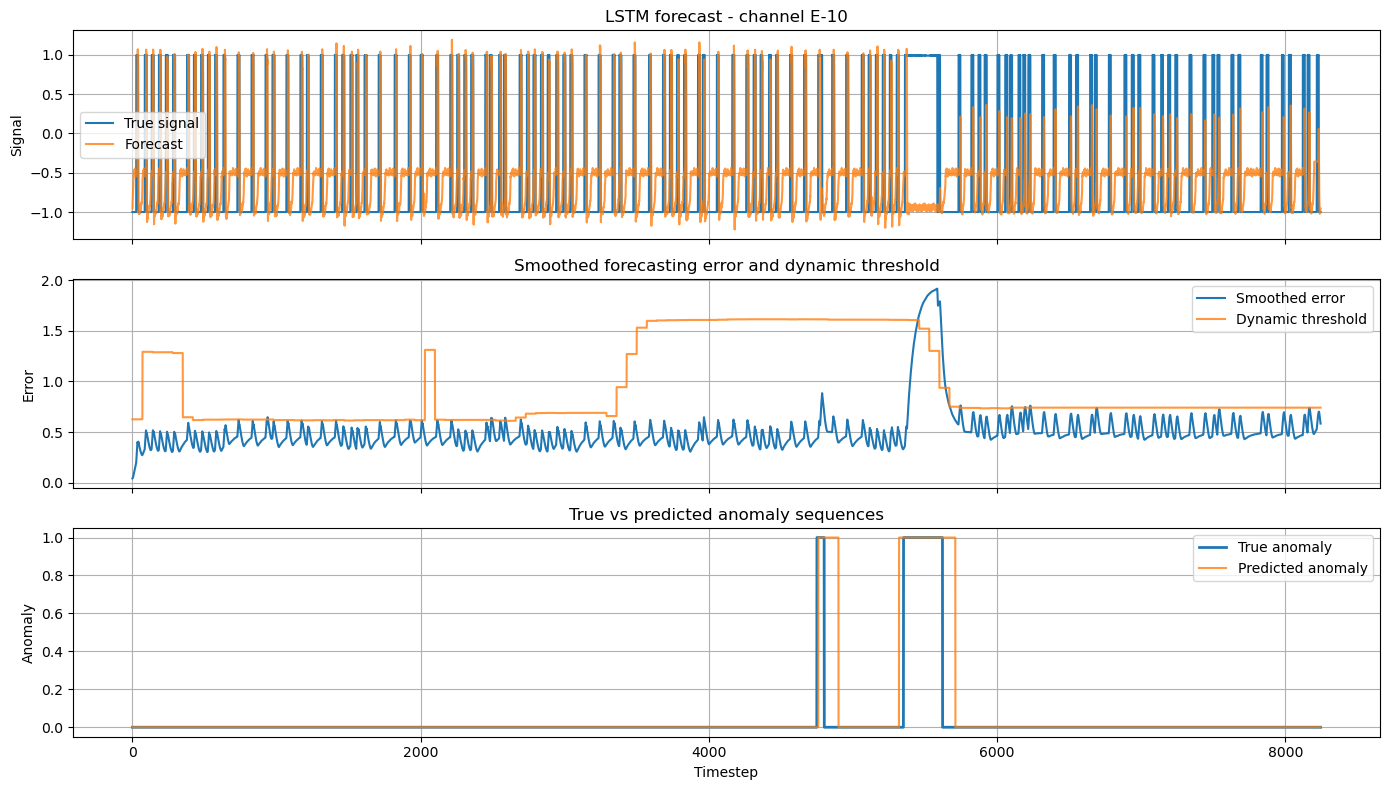

In [80]:
plot_lstm_channel_diagnostics("E-10")

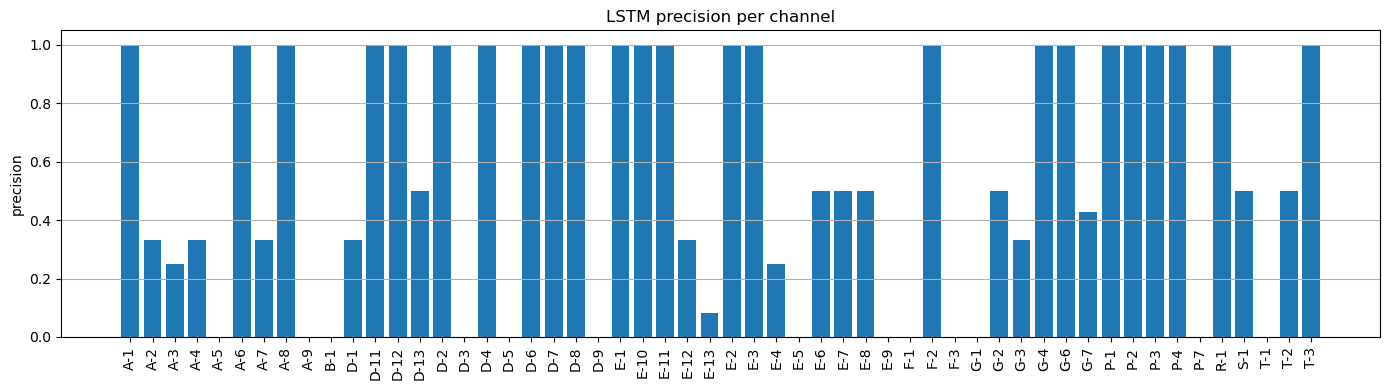

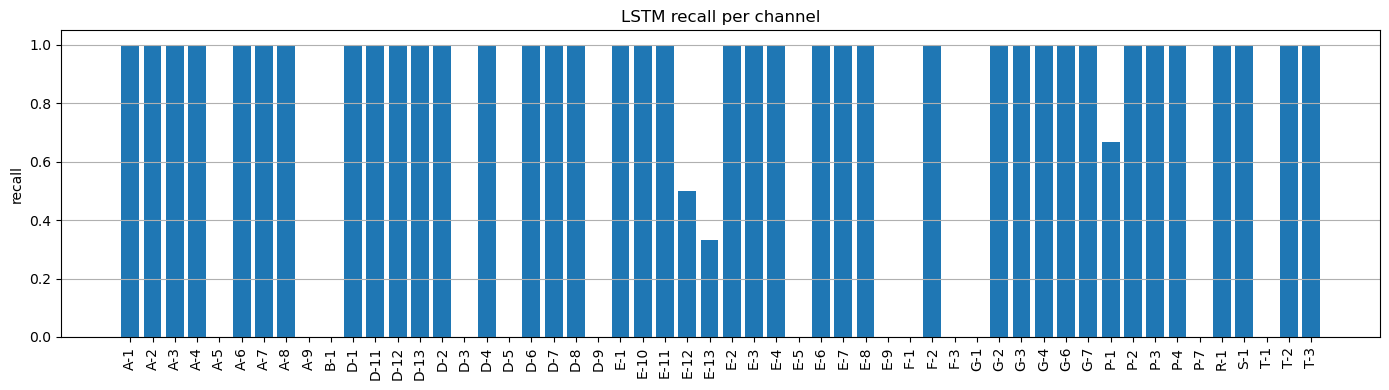

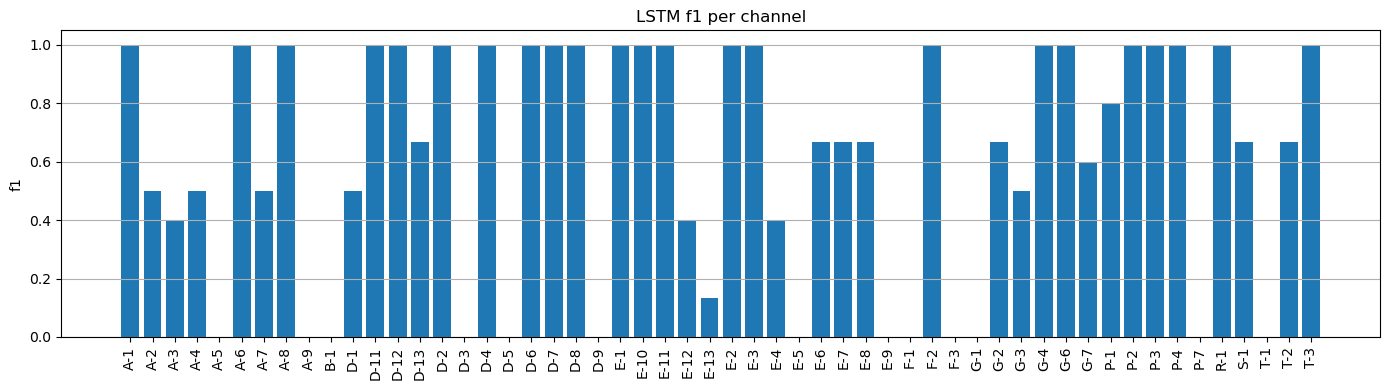

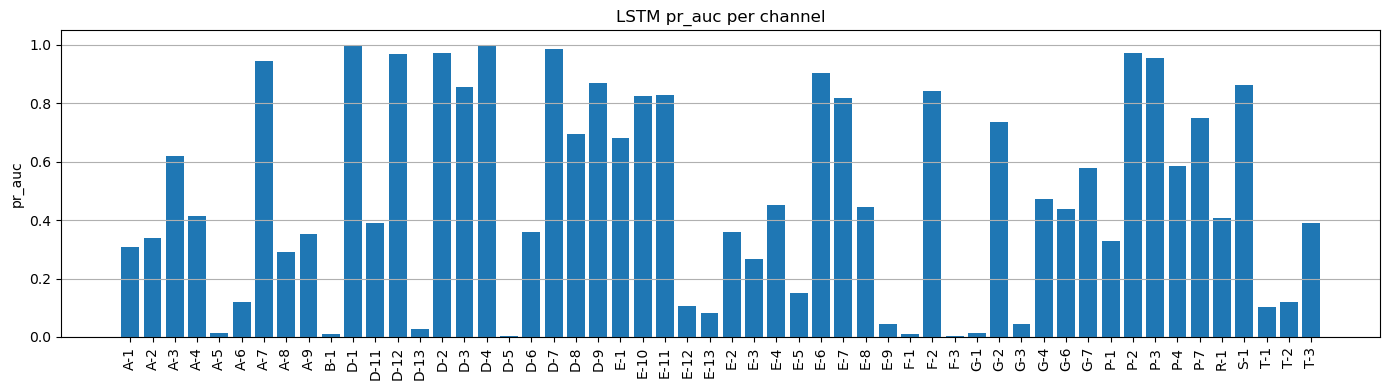

In [81]:
metrics_to_plot = ["precision", "recall", "f1", "pr_auc"]

for metric in metrics_to_plot:
    plt.figure(figsize=(14, 4))
    plt.bar(lstm_results_df["channel_id"], lstm_results_df[metric])
    plt.xticks(rotation=90)
    plt.ylabel(metric)
    plt.title(f"LSTM {metric} per channel")
    plt.grid(axis="y")
    plt.tight_layout()

    plt.show()